<a href="https://colab.research.google.com/github/dejanjovic1283-ui/imdb-sentiment-analysis-nlp/blob/main/imdb_sentiment_analysis_nlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMDB Sentiment Analysis using NLP and scikit-learn

This project demonstrates a professional Natural Language Processing (NLP) workflow for sentiment analysis using the IMDB movie review dataset.

The goal is to classify reviews as **positive** or **negative** using text preprocessing, TF-IDF vectorization, Logistic Regression, and hyperparameter tuning with GridSearchCV.

## Step 1: Install Required Libraries

In this step, we install the Python libraries required for data handling, text preprocessing, machine learning, and model saving.

In [22]:
!pip install -q pandas scikit-learn nltk matplotlib seaborn joblib tensorflow

## Step 2: Import Libraries

We import all required libraries for preprocessing, modeling, evaluation, and visualization.

In [23]:
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import nltk
from nltk.corpus import stopwords

from tensorflow.keras.datasets import imdb

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Step 3: Load the IMDB Dataset

We load the IMDB dataset from TensorFlow/Keras.

This dataset is already tokenized as integer sequences, so in the next step we will decode the sequences back into readable text.

In [24]:
# Load IMDB dataset
(X_train_raw, y_train), (X_test_raw, y_test) = imdb.load_data(num_words=10000)

print("Training samples:", len(X_train_raw))
print("Test samples:", len(X_test_raw))
print("First encoded review:", X_train_raw[0][:20])
print("First label:", y_train[0])

Training samples: 25000
Test samples: 25000
First encoded review: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
First label: 1


## Step 4: Decode Integer Sequences into Text

The IMDB dataset is stored as sequences of integers.  
We decode each sequence back into words so we can apply NLP preprocessing and vectorization.

In [25]:
# Get the word index
word_index = imdb.get_word_index()

# Reverse the word index
reverse_word_index = {value: key for key, value in word_index.items()}

def decode_review(encoded_review):
    return " ".join([reverse_word_index.get(i - 3, "?") for i in encoded_review])

# Decode train and test reviews
X_train_text = [decode_review(review) for review in X_train_raw]
X_test_text = [decode_review(review) for review in X_test_raw]

print("Sample decoded review:\n")
print(X_train_text[0][:1000])

Sample decoded review:

? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they

## Step 5: Create DataFrames

We organize the training and test data into pandas DataFrames for easier exploration and preprocessing.

In [26]:
train_df = pd.DataFrame({
    "review": X_train_text,
    "sentiment": y_train
})

test_df = pd.DataFrame({
    "review": X_test_text,
    "sentiment": y_test
})

print("Train DataFrame shape:", train_df.shape)
print("Test DataFrame shape:", test_df.shape)

train_df.head()

Train DataFrame shape: (25000, 2)
Test DataFrame shape: (25000, 2)


,review,sentiment
0,? this film was just brilliant casting locatio...,1
1,? big hair big boobs bad music and a giant saf...,0
2,? this has to be one of the worst films of the...,0
3,? the ? ? at storytelling the traditional sort...,1
4,? worst mistake of my life br br i picked this...,0


## Step 6: Explore the Dataset

We inspect the data structure and class distribution.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     25000 non-null  object
 1   sentiment  25000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 390.8+ KB
None

Training class distribution:

sentiment
1    12500
0    12500
Name: count, dtype: int64


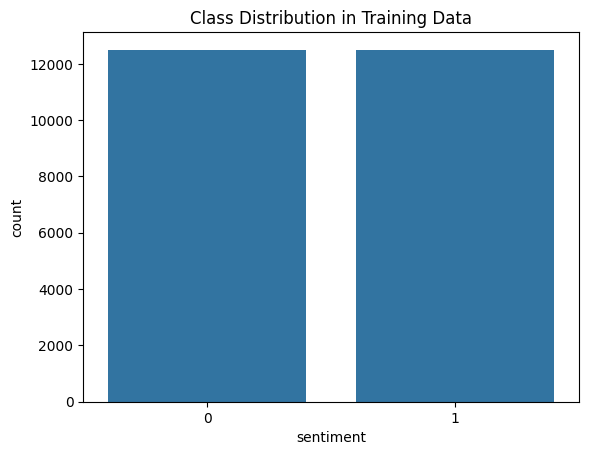

In [27]:
print(train_df.info())

print("\nTraining class distribution:\n")
print(train_df["sentiment"].value_counts())

sns.countplot(x="sentiment", data=train_df)
plt.title("Class Distribution in Training Data")
plt.show()

## Step 7: Define the Text Cleaning Function

We create a reusable preprocessing function that:
- converts text to lowercase
- removes non-letter characters
- removes English stopwords

In [28]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", "", text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

## Step 8: Apply Text Cleaning

We clean the training and test reviews using the preprocessing function.

In [29]:
train_df["review"] = train_df["review"].apply(clean_text)
test_df["review"] = test_df["review"].apply(clean_text)

train_df.head()

,review,sentiment
0,film brilliant casting location scenery story ...,1
1,big hair big boobs bad music giant safety pin ...,0
2,one worst films friends watching film target a...,0
3,storytelling traditional sort many years event...,1
4,worst mistake life br br picked movie target f...,0


## Step 9: Define Features and Target

We separate the text input (`review`) and the target labels (`sentiment`).

In [30]:
X_train = train_df["review"]
y_train = train_df["sentiment"]

X_test = test_df["review"]
y_test = test_df["sentiment"]

print("X_train size:", X_train.shape)
print("X_test size:", X_test.shape)

X_train size: (25000,)
X_test size: (25000,)


## Step 10: Build the NLP Pipeline

We create a production-style machine learning pipeline that includes:
- TF-IDF vectorization
- Logistic Regression classifier

In [31]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('model', LogisticRegression(max_iter=1000))])

## Step 11: Hyperparameter Tuning with GridSearchCV

We tune the model using GridSearchCV to search for stronger TF-IDF and Logistic Regression settings.

In [32]:
param_grid = {
    "tfidf__max_features": [5000, 8000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "model__C": [0.1, 1, 10]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters: {'model__C': 1, 'tfidf__max_features': 8000, 'tfidf__ngram_range': (1, 2)}
Best cross-validation score: 0.8863999676377743


## Step 12: Evaluate the Best Model

We evaluate the best model found by GridSearchCV on the test set.

In [33]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Test accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Test accuracy: 0.88608

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.88      0.89     12500
           1       0.89      0.89      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



## Step 12: Evaluate the Best Model

We evaluate the best model found by GridSearchCV on the test set.

In [34]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Test accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Test accuracy: 0.88608

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.88      0.89     12500
           1       0.89      0.89      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



## Step 13: Visualize the Confusion Matrix

We visualize the confusion matrix to better understand model performance.

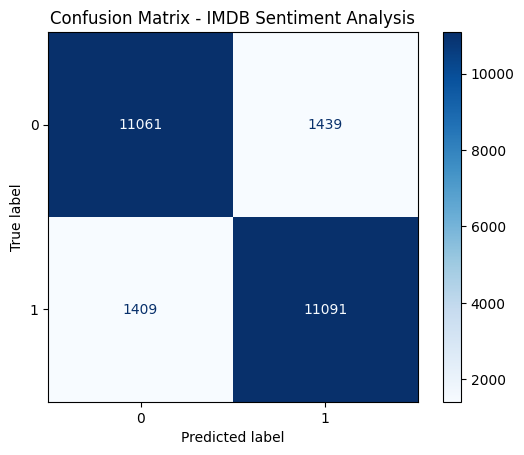

In [35]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - IMDB Sentiment Analysis")
plt.show()

## Step 14: Test Custom Review Predictions

We create a reusable prediction function and test the model on custom reviews.

In [36]:
def predict_sentiment(text):
    prediction = best_model.predict([text])[0]
    probabilities = best_model.predict_proba([text])[0]
    label = "Positive 😊" if prediction == 1 else "Negative 😡"
    return label, probabilities

sample_reviews = [
    "This movie was absolutely amazing and I loved every minute of it.",
    "This was one of the worst movies I have ever seen.",
    "The acting was decent, but the story felt weak and predictable.",
    "A brilliant film with powerful performances and excellent direction."
]

for review in sample_reviews:
    label, probabilities = predict_sentiment(review)
    print("Review:", review)
    print("Prediction:", label)
    print("Probabilities:", probabilities)
    print("-" * 80)

Review: This movie was absolutely amazing and I loved every minute of it.
Prediction: Positive 😊
Probabilities: [0.05870189 0.94129811]
--------------------------------------------------------------------------------
Review: This was one of the worst movies I have ever seen.
Prediction: Negative 😡
Probabilities: [0.9686013 0.0313987]
--------------------------------------------------------------------------------
Review: The acting was decent, but the story felt weak and predictable.
Prediction: Negative 😡
Probabilities: [0.98284139 0.01715861]
--------------------------------------------------------------------------------
Review: A brilliant film with powerful performances and excellent direction.
Prediction: Positive 😊
Probabilities: [0.00471217 0.99528783]
--------------------------------------------------------------------------------


## Step 15: Save the Trained Model

We save the best trained model so it can be reused in another notebook or deployed in a web application.

In [37]:
joblib.dump(best_model, "imdb_sentiment_model.pkl")
print("Model saved successfully")

Model saved successfully


## Step 16: Verify Saved Files

We verify that the trained model file exists in the working directory.

In [38]:
import os

print(os.listdir())

['.config', 'imdb_sentiment_model.pkl', 'sample_data']


## Conclusion

In this project, we built a professional NLP sentiment analysis pipeline using the IMDB dataset.

We completed the full workflow:
- dataset loading
- decoding text
- text preprocessing
- TF-IDF vectorization
- Logistic Regression training
- GridSearchCV tuning
- model evaluation
- confusion matrix visualization
- reusable predictions
- model saving

This project is portfolio-ready and demonstrates a complete NLP machine learning pipeline.